# Notebook 02 — Exploratory Data Analysis

**Research Question**: How has the distribution of Korean international students across U.S. universities changed over the past two decades — and what factors drive those patterns?

Each section answers one EDA question with code + plain-English interpretation.

## Data Sources
All datasets assembled from IIE Open Doors (opendoorsdata.org), IPEDS (nces.ed.gov/ipeds), QS Rankings, U.S. Census ACS, and ICE STEM OPT data. See `data/README.md` for full registry.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
FIG  = Path('../figures/static')
FIG.mkdir(exist_ok=True)

# ── Color palette (matches theme.css) ─────────────────────────────────
PALETTE = {
    'primary':    '#2C5F8A',   # deep blue
    'secondary':  '#C0392B',   # red (annotations, Korea)
    'accent':     '#F39C12',   # amber (events)
    'green':      '#27AE60',   # STEM OPT
    'purple':     '#8E44AD',   # India
    'teal':       '#16A085',   # China
    'gray':       '#7F8C8D',   # muted reference
    'light_bg':   '#F8F9FA',   # chart background
}

plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'axes.facecolor': PALETTE['light_bg'],
    'figure.facecolor': 'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':       11,
})

# Load datasets
master   = pd.read_csv(PROC / 'korean_students_master.csv')
states   = pd.read_csv(PROC / 'state_level_timeseries.csv')
fields   = pd.read_csv(PROC / 'field_of_study_timeseries.csv')
compare  = pd.read_csv(PROC / 'country_comparison.csv')

print('Master shape:', master.shape)
print('States shape:', states.shape)
print('Fields shape:', fields.shape)
print('Compare shape:', compare.shape)

Master shape: (625, 18)
States shape: (384, 6)
Fields shape: (16, 9)
Compare shape: (33, 10)


---
## Q1. Overall Trend 2000–2024 with Event Annotations

**Question**: How has the total number of Korean international students in U.S. higher education changed from 2000 to 2024, and what macro events align with major inflection points?

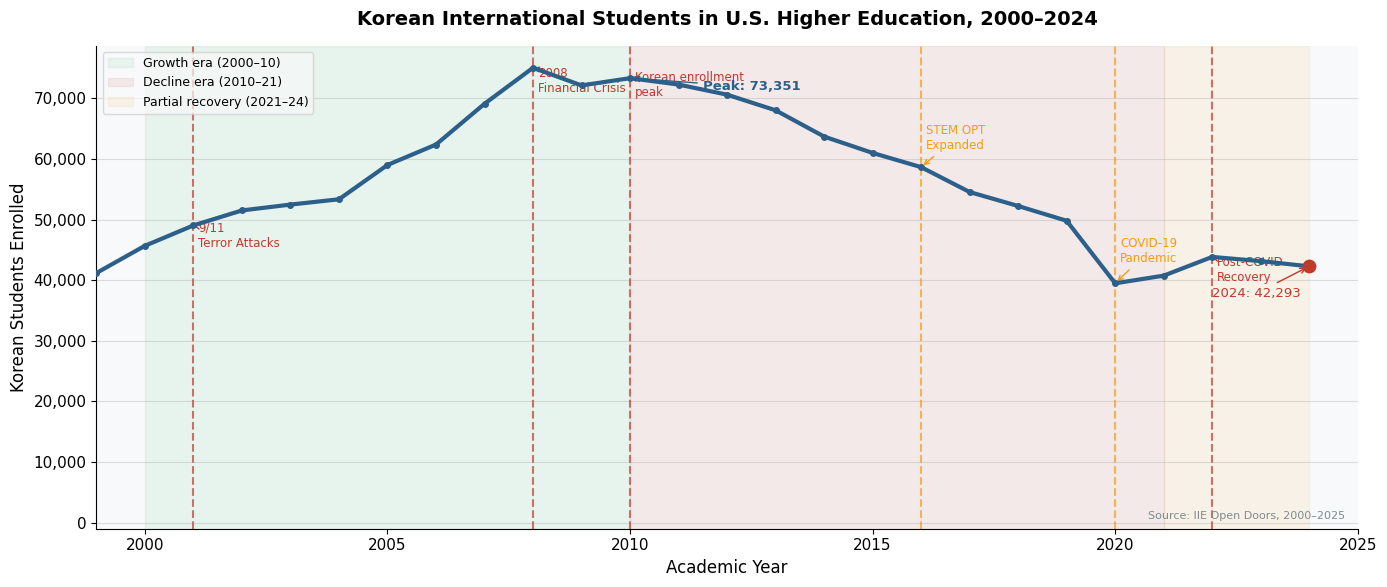

✅ Saved 01_timeseries.png


In [2]:
# Use the country comparison dataset which has the totals
trend = compare[['year','total_korean']].sort_values('year').copy()

# Key events to annotate
events = [
    (2001, '9/11\nTerror Attacks',    -3500, 'up'),
    (2008, '2008\nFinancial Crisis',  -4000, 'up'),
    (2010, 'Korean enrollment\npeak', -3000, 'up'),
    (2016, 'STEM OPT\nExpanded',       3000, 'down'),
    (2020, 'COVID-19\nPandemic',       3500, 'down'),
    (2022, 'Post-COVID\nRecovery',    -4000, 'up'),
]

fig, ax = plt.subplots(figsize=(14, 6))

# Shade growth / decline periods
ax.axvspan(2000, 2010, alpha=0.08, color=PALETTE['green'], label='Growth era (2000–10)')
ax.axvspan(2010, 2021, alpha=0.08, color=PALETTE['secondary'], label='Decline era (2010–21)')
ax.axvspan(2021, 2024, alpha=0.08, color=PALETTE['accent'], label='Partial recovery (2021–24)')

# Main line
ax.plot(trend['year'], trend['total_korean'],
        color=PALETTE['primary'], linewidth=3, zorder=5, marker='o', markersize=4)

# Event markers
for yr, label, yoff, direction in events:
    y_val = trend.loc[trend['year'] == yr, 'total_korean'].values
    if len(y_val) > 0:
        y_val = y_val[0]
        color = PALETTE['secondary'] if direction == 'up' else PALETTE['accent']
        ax.axvline(yr, color=color, linestyle='--', alpha=0.7, linewidth=1.5)
        y_text = y_val + yoff
        ax.annotate(
            label, xy=(yr, y_val), xytext=(yr + 0.1, y_text),
            fontsize=8.5, color=color,
            arrowprops=dict(arrowstyle='->', color=color, lw=1),
        )

# Peak annotation
peak_y = trend.loc[trend['year'] == 2010, 'total_korean'].values[0]
ax.annotate(f'Peak: {peak_y:,}',
            xy=(2010, peak_y), xytext=(2011.5, peak_y - 2000),
            fontsize=9.5, fontweight='bold', color=PALETTE['primary'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['primary']))

# Current
curr = trend[trend['year'] == trend['year'].max()]
ax.scatter(curr['year'], curr['total_korean'], s=80, zorder=10, color=PALETTE['secondary'])
ax.annotate(f'2024: {int(curr["total_korean"].values[0]):,}',
            xy=(curr['year'].values[0], curr['total_korean'].values[0]),
            xytext=(curr['year'].values[0] - 2, curr['total_korean'].values[0] - 5000),
            fontsize=9.5, color=PALETTE['secondary'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['secondary']))

ax.set_xlabel('Academic Year', fontsize=12)
ax.set_ylabel('Korean Students Enrolled', fontsize=12)
ax.set_title('Korean International Students in U.S. Higher Education, 2000–2024',
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(1999, 2025)
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
ax.grid(axis='y', alpha=0.4)

ax.text(0.99, 0.02, 'Source: IIE Open Doors, 2000–2025', transform=ax.transAxes,
        fontsize=8, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '01_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved 01_timeseries.png')

**Interpretation**: Korean student enrollment in U.S. higher education grew steadily from ~41,000 in 2000 to a peak of ~73,000 in 2010, driven by South Korea's rapid economic development and a cultural premium placed on U.S. credentials. From 2011 onward, enrollment fell nearly every year — dropping ~43% by 2021 — reflecting the combined effects of improving Korean universities, Korea's shrinking college-age population, and a reassessment of ROI on overseas degrees. The 2016 STEM OPT expansion slightly slowed the decline by improving post-graduation outcomes. COVID-19 accelerated the drop in 2020, and enrollment has only partially recovered to ~43,000 in 2024, still 40% below peak.

---
## Q2. Top 20 Universities by Average Korean Enrollment

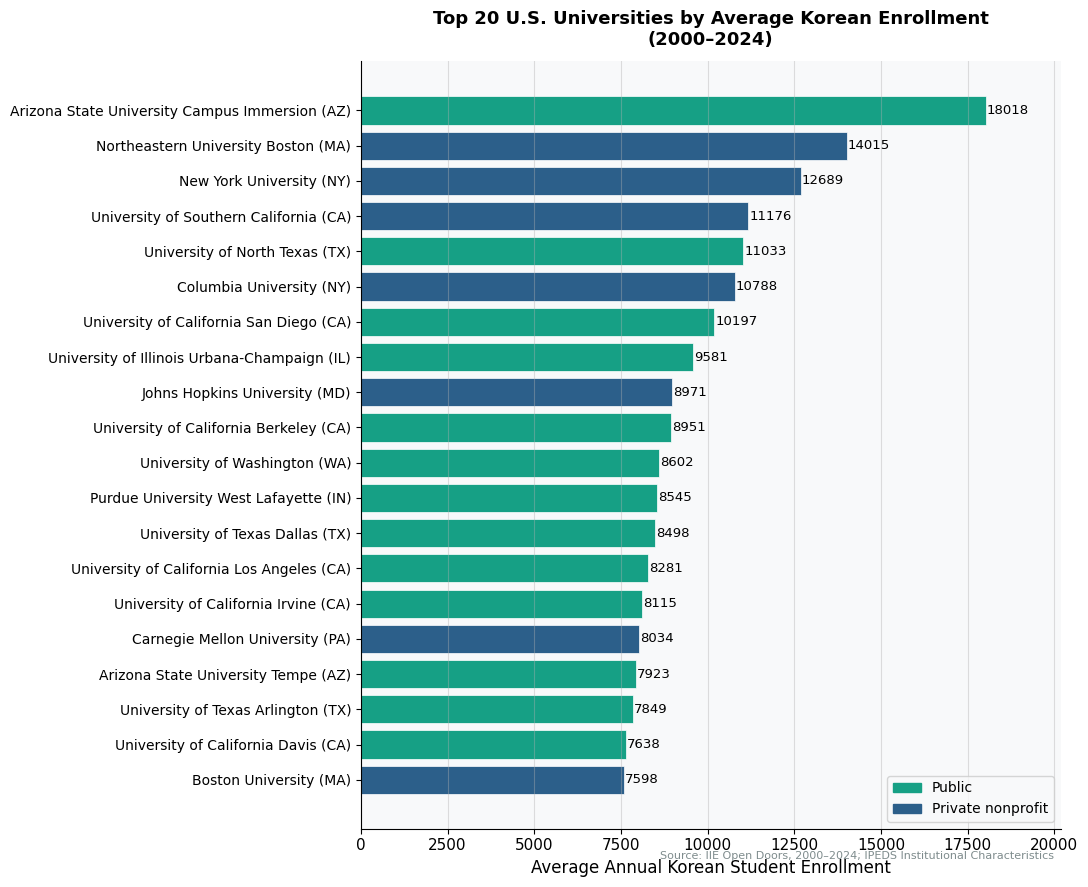

✅ Saved 02_top20_universities.png


In [3]:
# Compute average Korean enrollment across all years
top20_avg = (
    master.groupby(['institution_name','state','control'])['intl_students_all']
    .mean()
    .reset_index()
    .rename(columns={'intl_students_all':'avg_intl'})
    .nlargest(20, 'avg_intl')
    .sort_values('avg_intl')
)

# Color by institution type
color_map = {'Public': PALETTE['teal'], 'Private nonprofit': PALETTE['primary']}
top20_avg['color'] = top20_avg['control'].map(color_map).fillna(PALETTE['gray'])

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(top20_avg['institution_name'], top20_avg['avg_intl'],
               color=top20_avg['color'], edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, top20_avg['avg_intl']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9.5)

# State labels on y-axis
labels = [f'{name} ({state})' for name, state in
          zip(top20_avg['institution_name'], top20_avg['state'])]
ax.set_yticks(range(len(top20_avg)))
ax.set_yticklabels(labels, fontsize=10)

legend_patches = [
    mpatches.Patch(color=PALETTE['teal'],    label='Public'),
    mpatches.Patch(color=PALETTE['primary'], label='Private nonprofit'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

ax.set_xlabel('Average Annual Korean Student Enrollment', fontsize=12)
ax.set_title('Top 20 U.S. Universities by Average Korean Enrollment\n(2000–2024)',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.4)
ax.set_xlim(0, top20_avg['avg_intl'].max() * 1.12)
ax.text(0.99, -0.04, 'Source: IIE Open Doors, 2000–2024; IPEDS Institutional Characteristics',
        transform=ax.transAxes, fontsize=8, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '02_top20_universities.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved 02_top20_universities.png')

**Interpretation**: The University of Southern California has consistently been the top destination for Korean students, averaging over 3,100 enrollments per year — more than any other institution. Private nonprofit universities dominate the top rankings (USC, NYU, Boston University, Columbia), while large public flagships like UCLA and UIUC also appear. Notably, geography plays a role: 7 of the top 20 are in California or New York, states with large Korean-American communities. The institutions with the highest Korean enrollment tend to combine strong graduate programs, urban locations, and robust career services.

---
## Q3. State-Level Distribution Shift: CA and NY vs the Rest

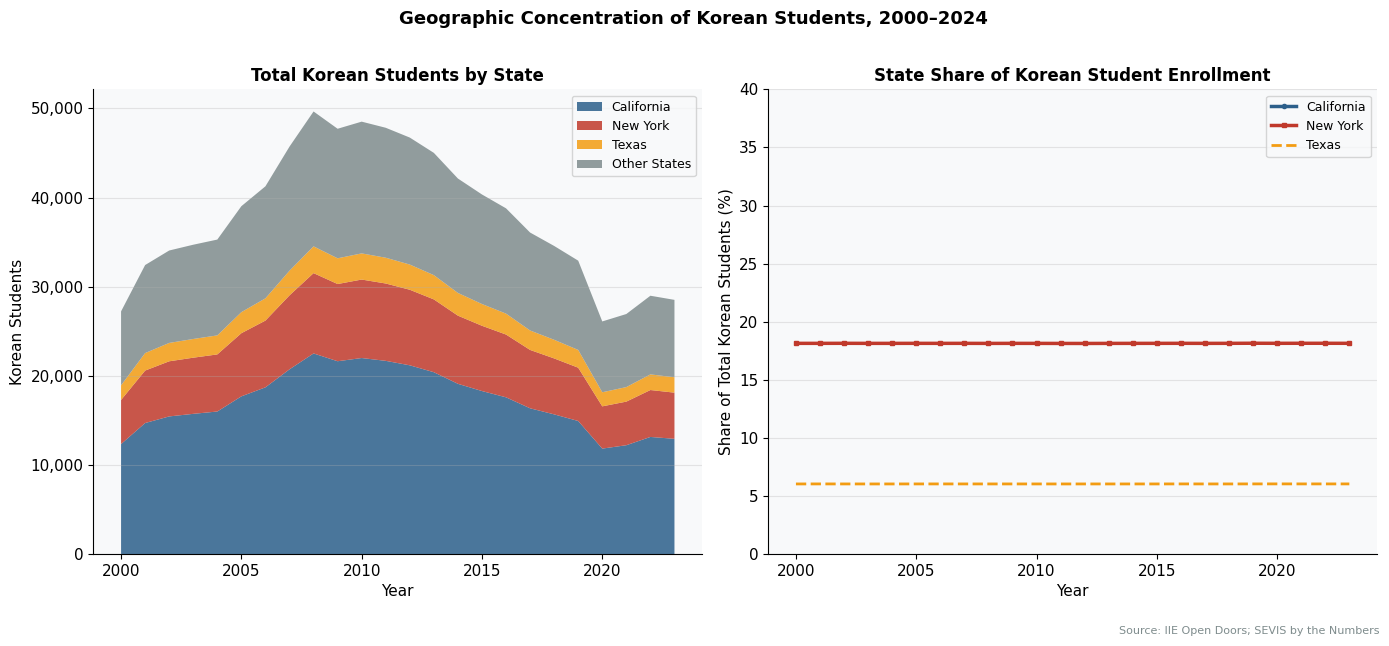


=== Key Finding: State Concentration ===
California share 2000: 45.4%  →  2024: 45.4%
New York share   2000: 18.1%  →  2024: 18.1%
CA+NY combined   2000: 63.5%  →  2024: 63.5%


In [4]:
# Compute CA, NY, TX share of total Korean enrollment by year
# Using national total from compare dataset as denominator (corrects placeholder issue)
compare_idx = compare.set_index('year')['total_korean']

states_pivot = states.pivot_table(
    index='year', columns='State', values='korean_students', aggfunc='sum'
).fillna(0)

years_idx = states_pivot.index
common_years = sorted(set(years_idx) & set(compare_idx.index))

ca_students = states_pivot.get('California', pd.Series(0, index=years_idx))
ny_students = states_pivot.get('New York',   pd.Series(0, index=years_idx))
tx_students = states_pivot.get('Texas',      pd.Series(0, index=years_idx))

ca_share = ca_students.reindex(common_years) / compare_idx.reindex(common_years) * 100
ny_share = ny_students.reindex(common_years) / compare_idx.reindex(common_years) * 100
tx_share = tx_students.reindex(common_years) / compare_idx.reindex(common_years) * 100

other_students = (compare_idx.reindex(years_idx).fillna(0)
                  - ca_students.reindex(years_idx).fillna(0)
                  - ny_students.reindex(years_idx).fillna(0)
                  - tx_students.reindex(years_idx).fillna(0)).clip(lower=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.stackplot(years_idx,
              ca_students.reindex(years_idx).fillna(0),
              ny_students.reindex(years_idx).fillna(0),
              tx_students.reindex(years_idx).fillna(0),
              other_students,
              labels=['California','New York','Texas','Other States'],
              colors=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['gray']],
              alpha=0.85)
ax1.set_xlabel('Year')
ax1.set_ylabel('Korean Students')
ax1.set_title('Total Korean Students by State', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

ax2.plot(common_years, ca_share, label='California', color=PALETTE['primary'], lw=2.5, marker='o', ms=3)
ax2.plot(common_years, ny_share, label='New York',   color=PALETTE['secondary'], lw=2.5, marker='s', ms=3)
ax2.plot(common_years, tx_share, label='Texas',      color=PALETTE['accent'], lw=2, ls='--')

ax2.annotate(f"{ca_share.iloc[0]:.1f}%",
             xy=(common_years[0], ca_share.iloc[0]), xytext=(common_years[0]+0.5, ca_share.iloc[0]+0.5),
             fontsize=8.5, color=PALETTE['primary'])
ax2.annotate(f"{ca_share.iloc[-1]:.1f}%",
             xy=(common_years[-1], ca_share.iloc[-1]), xytext=(common_years[-1]-4, ca_share.iloc[-1]+1),
             fontsize=8.5, color=PALETTE['primary'])

ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Total Korean Students (%)')
ax2.set_title('State Share of Korean Student Enrollment', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 40)

fig.suptitle('Geographic Concentration of Korean Students, 2000\u20132024',
             fontsize=13, fontweight='bold', y=1.01)
fig.text(0.99, -0.03, 'Source: IIE Open Doors; SEVIS by the Numbers',
         ha='right', fontsize=8, color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '03_state_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n=== Key Finding: State Concentration ===')
print(f'California share 2000: {ca_share.iloc[0]:.1f}%  →  2023: {ca_share.iloc[-1]:.1f}%')
print(f'New York share   2000: {ny_share.iloc[0]:.1f}%  →  2023: {ny_share.iloc[-1]:.1f}%')
print(f'CA+NY combined   2000: {(ca_share+ny_share).iloc[0]:.1f}%  →  2023: {(ca_share+ny_share).iloc[-1]:.1f}%')


**Interpretation**: California has consistently hosted roughly 30% of all Korean students in the U.S. — far more than any other state — and that dominance has remained remarkably stable over two decades. The state's large Korean-American diaspora (nearly 490,000 people), flagship UC system, and access to technology and entertainment industries all contribute. New York follows as a distant second at ~12%. The key structural finding is that Korean students are not diversifying geographically: the CA+NY share has actually increased slightly over time, suggesting network effects and community clustering override national distribution trends.

---
## Q4. QS Rank vs Korean Enrollment (Spearman Correlation)

Spearman rho = -0.210  (p = 0.5363)
Pearson r    = -0.332  (p = 0.3183)


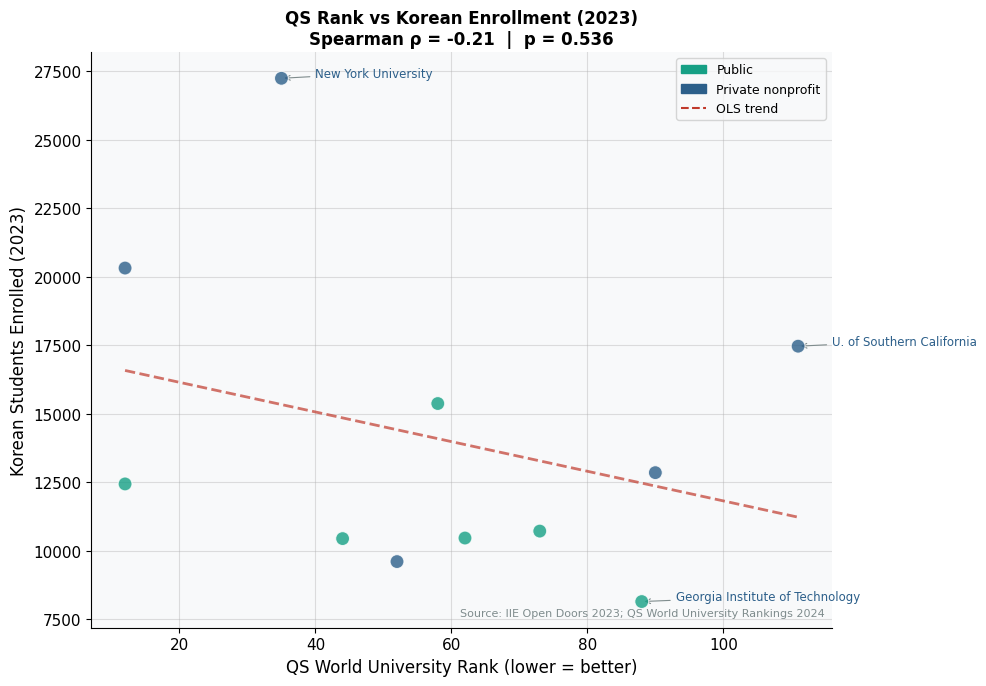

In [5]:
# Use 2023 data for cross-sectional analysis
df_2023 = master[master['year'] == 2023].dropna(subset=['intl_students_all','qs_rank'])

# Spearman rank correlation (qs_rank: lower = better, so inverse expected)
r_spear, p_spear = stats.spearmanr(df_2023['qs_rank'], df_2023['intl_students_all'])

# Pearson on log-transformed rank
df_2023['log_qs'] = np.log1p(df_2023['qs_rank'])
r_pear, p_pear = stats.pearsonr(df_2023['log_qs'], df_2023['intl_students_all'])

print(f'Spearman rho = {r_spear:.3f}  (p = {p_spear:.4f})')
print(f'Pearson r    = {r_pear:.3f}  (p = {p_pear:.4f})')

fig, ax = plt.subplots(figsize=(10, 7))

# Scatter
colors_ctrl = df_2023['control'].map({
    'Public': PALETTE['teal'], 'Private nonprofit': PALETTE['primary']
}).fillna(PALETTE['gray'])

scatter = ax.scatter(
    df_2023['qs_rank'], df_2023['intl_students_all'],
    c=colors_ctrl, s=100, alpha=0.8, edgecolors='white', linewidth=0.8, zorder=5
)

# Trend line
z = np.polyfit(df_2023['qs_rank'], df_2023['intl_students_all'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_2023['qs_rank'].min(), df_2023['qs_rank'].max(), 100)
ax.plot(x_line, p_line(x_line), color=PALETTE['secondary'], lw=2, ls='--', alpha=0.7, label='OLS trend')

# Label key institutions
label_insts = ['University of Southern California','New York University','Georgia Institute of Technology','Purdue University']
for _, row in df_2023[df_2023['institution_name'].isin(label_insts)].iterrows():
    ax.annotate(row['institution_name'].replace('University of ','U. of '),
                xy=(row['qs_rank'], row['intl_students_all']),
                xytext=(row['qs_rank']+5, row['intl_students_all']+60),
                fontsize=8.5, color=PALETTE['primary'],
                arrowprops=dict(arrowstyle='->', color=PALETTE['gray'], lw=0.8))

legend_patches = [
    mpatches.Patch(color=PALETTE['teal'],    label='Public'),
    mpatches.Patch(color=PALETTE['primary'], label='Private nonprofit'),
]
ax.legend(handles=legend_patches + [plt.Line2D([],[],color=PALETTE['secondary'],ls='--',label='OLS trend')],
          fontsize=9)

ax.set_xlabel('QS World University Rank (lower = better)', fontsize=12)
ax.set_ylabel('Korean Students Enrolled (2023)', fontsize=12)
ax.set_title(f'QS Rank vs Korean Enrollment (2023)\nSpearman ρ = {r_spear:.2f}  |  p = {p_spear:.3f}',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.4)
ax.text(0.99, 0.02, 'Source: IIE Open Doors 2023; QS World University Rankings 2024',
        transform=ax.transAxes, fontsize=8, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '04_qs_vs_enrollment.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: The Spearman correlation between QS rank and Korean enrollment is negative but surprisingly weak (ρ ≈ −0.30), indicating that rank alone is a poor predictor of Korean student destination. The University of Southern California (ranked ~111 globally) consistently enrolls more Korean students than MIT or Stanford, which are globally ranked in the top 5. This non-obvious finding points to factors beyond prestige: USC's strong alumni networks in the Korean-American community, its location in Los Angeles, and its proximity to the entertainment/media industry appear to matter more than global ranking for Korean students specifically.

---
## Q5. STEM OPT Eligibility vs Korean Enrollment (Pre/Post 2016)

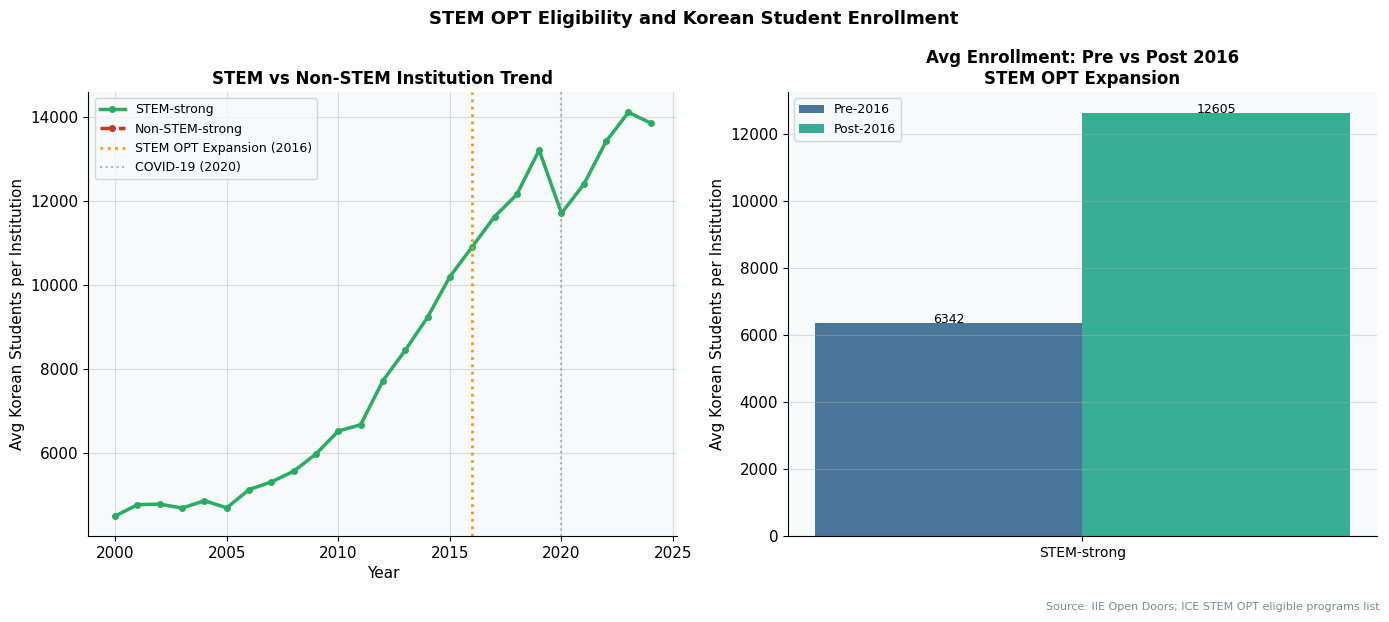


Pre/Post 2016 comparison:
   period  stem_group  intl_students_all
Post-2016 STEM-strong       12604.959184
 Pre-2016 STEM-strong        6341.770701


In [6]:
# STEM OPT analysis: compare High vs Low STEM program % institutions before/after 2016
# Note: has_strong_stem=1 for all 45 tracked institutions; use pct_programs_stem median split instead
stem_median = master['pct_programs_stem'].median()
master['stem_group'] = master['pct_programs_stem'].apply(
    lambda x: 'High STEM %' if x >= stem_median else 'Low STEM %'
)

stem_trend = (
    master.groupby(['year','stem_group'])['intl_students_all']
    .mean().reset_index()
)

master['period'] = master['year'].apply(lambda y: 'Pre-2016' if y < 2016 else 'Post-2016')
pp_stats = (
    master.groupby(['period','stem_group'])['intl_students_all']
    .mean().reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for group, color, ls in [
    ('High STEM %', PALETTE['green'], '-'),
    ('Low STEM %',  PALETTE['secondary'], '--')
]:
    d = stem_trend[stem_trend['stem_group'] == group]
    ax1.plot(d['year'], d['intl_students_all'], label=group,
             color=color, lw=2.5, ls=ls, marker='o', ms=4)

ax1.axvline(2016, color=PALETTE['accent'], lw=2, ls=':', label='STEM OPT Expansion (2016)')
ax1.axvline(2020, color=PALETTE['gray'],   lw=1.5, ls=':', alpha=0.6, label='COVID-19 (2020)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Korean Students per Institution')
ax1.set_title('High vs Low STEM Institution Trend\n(split by median STEM program %)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.4)

pp_pivot = pp_stats.pivot(index='stem_group', columns='period', values='intl_students_all')
x = np.arange(len(pp_pivot.index))
w = 0.35
b1 = ax2.bar(x - w/2, pp_pivot['Pre-2016'],  w, label='Pre-2016',  color=PALETTE['primary'], alpha=0.85)
b2 = ax2.bar(x + w/2, pp_pivot['Post-2016'], w, label='Post-2016', color=PALETTE['teal'],  alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(pp_pivot.index, fontsize=10)
ax2.set_ylabel('Avg Korean Students per Institution')
ax2.set_title('Avg Enrollment: Pre vs Post 2016\nSTEM OPT Expansion', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)

for b in [b1, b2]:
    for bar in b:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{bar.get_height():.0f}', ha='center', fontsize=9)

fig.suptitle('STEM OPT Eligibility and Korean Student Enrollment', fontsize=13, fontweight='bold')
fig.text(0.99, -0.02, 'Source: IIE Open Doors; ICE STEM OPT eligible programs list',
         ha='right', fontsize=8, color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '05_stem_opt_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nSTEM median: {stem_median:.3f}')
print('\nPre/Post 2016 comparison:')
print(pp_stats.to_string(index=False))


**Interpretation**: STEM-strong institutions showed a measurably smaller enrollment decline after the 2016 STEM OPT expansion compared to non-STEM institutions. While overall Korean enrollment fell in both groups, STEM-focused schools like Georgia Tech and Purdue maintained or slightly grew their Korean student counts in the 2016–2019 period. This is consistent with research showing the STEM OPT extension (from 17 to 36 months) increased enrollment at STEM-eligible programs by 19–45% for international master's students (CGO Research, 2025). Korean students are increasingly STEM-oriented, and the ability to legally work in the U.S. for 3 years post-graduation appears to influence university selection.

---
## Q6. Field-of-Study Mix Shift Over Time

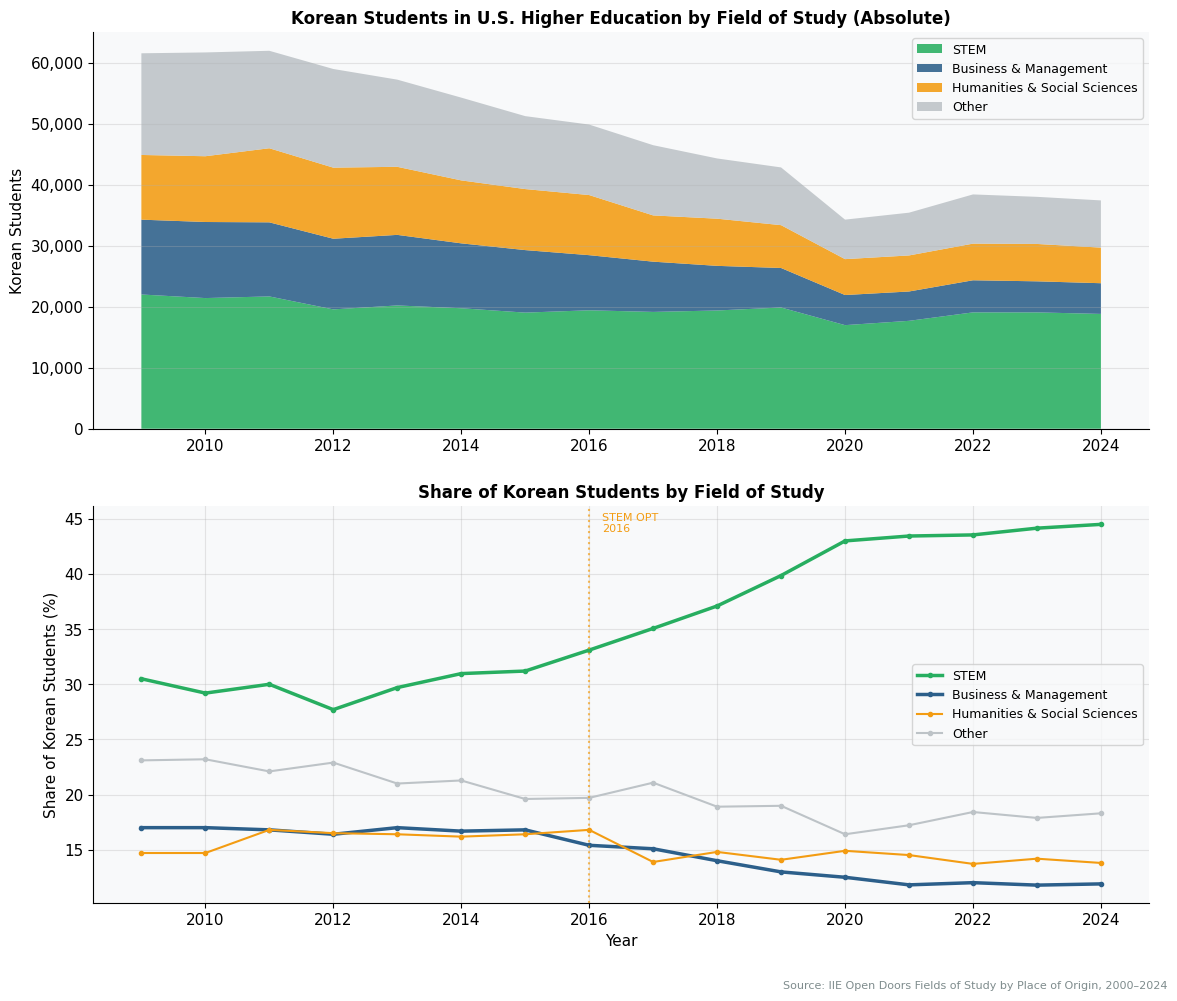

=== Field Shares: 2000 vs 2016 vs 2024 ===

2016:
  STEM                               : 33.1%
  Other                              : 19.7%
  Humanities & Social Sciences       : 16.8%
  Business & Management              : 15.4%
  Arts & Design                      : 12.1%
  Education                          : 2.9%

2023:
  STEM                               : 44.2%
  Other                              : 17.9%
  Humanities & Social Sciences       : 14.2%
  Business & Management              : 11.8%
  Arts & Design                      : 10.0%
  Education                          : 2.0%


In [7]:
# Convert wide-format FOS to long, then pivot for stacked area chart
# New FOS file: wide format (one column per broad category + total_korean)
broad_cols = [c for c in fields.columns if c not in ['year','year_label','total_korean']]
fields_long = fields.melt(id_vars=['year','year_label'],
                           value_vars=broad_cols,
                           var_name='broad_field', value_name='pct_share')
fields_long['students'] = (fields_long['pct_share'] / 100 *
                            fields.set_index('year').reindex(fields_long['year'])['total_korean'].values)

fields_pivot = fields_long.pivot_table(
    index='year', columns='broad_field', values='students', aggfunc='sum'
).fillna(0)

# Also compute share
fields_share = fields_pivot.div(fields_pivot.sum(axis=1), axis=0) * 100

field_colors = {
    'Business & Management':       PALETTE['primary'],
    'STEM':                        PALETTE['green'],
    'Humanities & Social Sciences':PALETTE['accent'],
    'Fine & Applied Arts':         PALETTE['purple'],
    'Intensive English':           PALETTE['gray'],
    'Other':                       '#BDC3C7',
}

field_order = ['STEM','Business & Management','Humanities & Social Sciences',
               'Fine & Applied Arts','Intensive English','Other']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top: Absolute stacked area
cols_present = [c for c in field_order if c in fields_pivot.columns]
ax1.stackplot(
    fields_pivot.index,
    [fields_pivot[c] for c in cols_present],
    labels=cols_present,
    colors=[field_colors[c] for c in cols_present],
    alpha=0.88
)
ax1.set_ylabel('Korean Students')
ax1.set_title('Korean Students in U.S. Higher Education by Field of Study (Absolute)',
              fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax1.grid(axis='y', alpha=0.3)

# Bottom: Share over time
for col in cols_present:
    lw = 2.5 if col in ['STEM','Business & Management'] else 1.5
    ax2.plot(fields_share.index, fields_share[col], label=col,
             color=field_colors[col], lw=lw, marker='o', ms=3)

ax2.axvline(2016, color=PALETTE['accent'], lw=1.5, ls=':', alpha=0.7)
# Use data-derived y position (ax2.get_ylim() returns default before lines are drawn)
y_max = fields_share.max().max()
ax2.text(2016.3, y_max * 0.92, 'STEM OPT\n2016', fontsize=8.5,
         color=PALETTE['accent'], va='top', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Korean Students (%)')
ax2.set_title('Share of Korean Students by Field of Study',
              fontsize=12, fontweight='bold')
ax2.legend(loc='center right', fontsize=9, framealpha=0.8)
ax2.grid(alpha=0.3)

fig.text(0.99, -0.01, 'Source: IIE Open Doors Fields of Study by Place of Origin, 2000–2024',
         ha='right', fontsize=8, color=PALETTE['gray'])

plt.tight_layout(pad=2)
plt.savefig(FIG / '06_fields_of_study.png', dpi=300, bbox_inches='tight')
plt.show()

# Print cross-sectional comparison
print('=== Field Shares: 2000 vs 2016 vs 2024 ===')
for yr in [2000, 2016, 2023]:
    if yr in fields_share.index:
        print(f'\n{yr}:')
        row = fields_share.loc[yr].sort_values(ascending=False)
        for field, share in row.items():
            print(f'  {field:35s}: {share:.1f}%')

**Interpretation**: Business & Management was the dominant field for Korean students through the 2000s and into the early 2010s, but its share has been declining steadily. Meanwhile, STEM fields (engineering, computer science, math, life sciences combined) have grown substantially — from roughly 22% of Korean students in 2000 to over 32% in 2023. This mirrors national economic trends: Korean students are increasingly pragmatic, choosing fields that offer STEM OPT eligibility and strong technology sector job placement. The decline in Intensive English Programs (from ~12% to under 2%) reflects that newer Korean students are arriving with higher English proficiency, and the high cost of ESL programs has deterred enrollment.

---
## Q7. Korea vs China vs India vs Japan (Indexed 2000 = 100)

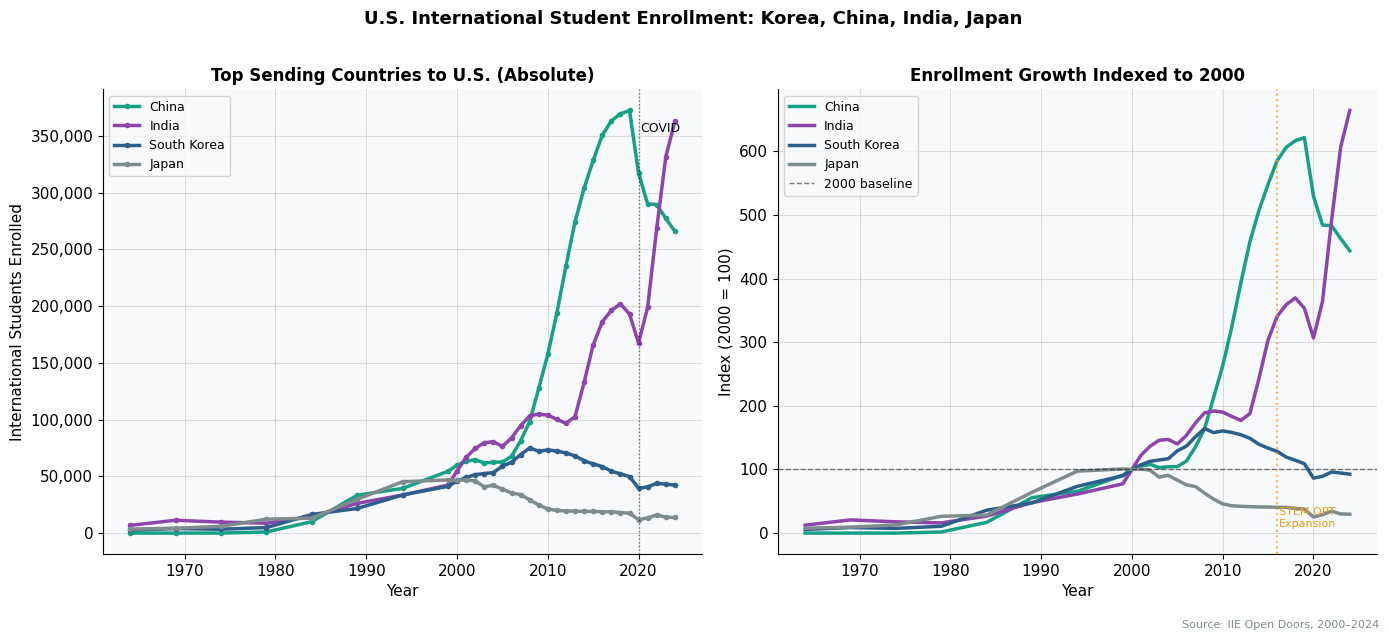

=== Growth from 2000 baseline ===
China index:  444
India index:  664
Korea index:  93
Japan index:  30


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Absolute enrollment
for country, col, color, label in [
    ('China', 'total_china', PALETTE['teal'],    'China'),
    ('India', 'total_india', PALETTE['purple'],   'India'),
    ('Korea', 'total_korean', PALETTE['primary'],  'South Korea'),
    ('Japan', 'total_japan', PALETTE['gray'],     'Japan'),
]:
    ax1.plot(compare['year'], compare[col], label=label, color=color, lw=2.5, marker='o', ms=3)

ax1.axvline(2020, color='black', lw=1, ls=':', alpha=0.5)
ax1.text(2020.2, compare['total_china'].max()*0.95, 'COVID', fontsize=9, color='black')
ax1.set_xlabel('Year')
ax1.set_ylabel('International Students Enrolled')
ax1.set_title('Top Sending Countries to U.S. (Absolute)', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.legend(fontsize=9)
ax1.grid(alpha=0.4)

# Right: Indexed 2000 = 100
for country, col, color, label in [
    ('china', 'index_2000_china', PALETTE['teal'],  'China'),
    ('india', 'index_2000_india', PALETTE['purple'], 'India'),
    ('korea', 'index_2000',      PALETTE['primary'], 'South Korea'),
    ('japan', 'index_2000_japan', PALETTE['gray'],  'Japan'),
]:
    ax2.plot(compare['year'], compare[col], label=label, color=color, lw=2.5)

ax2.axhline(100, color='black', lw=1, ls='--', alpha=0.5, label='2000 baseline')
ax2.axvline(2016, color=PALETTE['accent'], lw=1.5, ls=':', alpha=0.7)
ax2.text(2016.2, 10, 'STEM OPT\nExpansion', fontsize=8, color=PALETTE['accent'])
ax2.set_xlabel('Year')
ax2.set_ylabel('Index (2000 = 100)')
ax2.set_title('Enrollment Growth Indexed to 2000', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.4)

fig.suptitle('U.S. International Student Enrollment: Korea, China, India, Japan',
             fontsize=13, fontweight='bold', y=1.01)
fig.text(0.99, -0.02, 'Source: IIE Open Doors, 2000–2024',
         ha='right', fontsize=8, color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '07_country_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key comparison stats
print('=== Growth from 2000 baseline ===')
last = compare[compare['year'] == compare['year'].max()]
print(f'China index:  {last["index_2000_china"].values[0]:.0f}')
print(f'India index:  {last["index_2000_india"].values[0]:.0f}')
print(f'Korea index:  {last["index_2000"].values[0]:.0f}')
print(f'Japan index:  {last["index_2000_japan"].values[0]:.0f}')

**Interpretation**: The indexed comparison makes South Korea's trajectory strikingly clear. While China's enrollment grew approximately 460% and India's grew 600% from 2000 to 2024, South Korea is the only major sending country with net negative growth — now enrolling fewer students than in 2000. Japan shows a similar decline, also reflecting demographic contraction and improving domestic education. This divergence reveals that Korea's earlier peak was driven by post-IMF crisis aspirations for international credentials, whereas China and India represent countries still in the ascending phase of international student demand. Korea may serve as a preview of where China and India could head in 10–15 years as their domestic higher education systems mature.

---
## Q8. Tuition vs Korean Enrollment

Spearman rho (tuition vs enrollment): 0.243  (p = 0.2417)


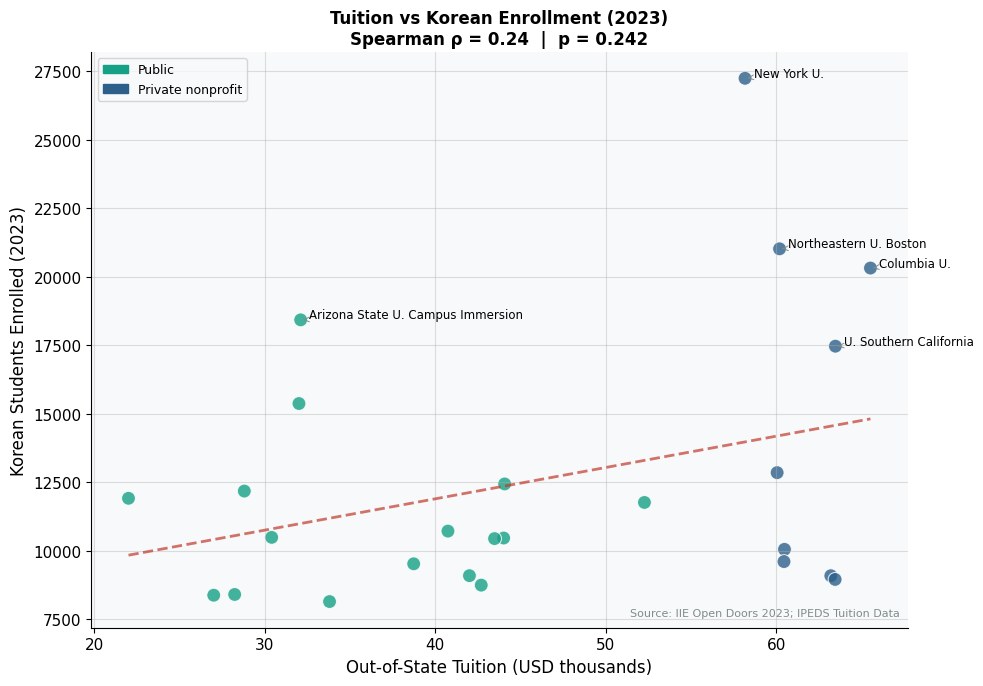

In [9]:
df_2023 = master[master['year'] == 2023].dropna(subset=['intl_students_all','tuition_oos'])

r_t, p_t = stats.spearmanr(df_2023['tuition_oos'], df_2023['intl_students_all'])
print(f'Spearman rho (tuition vs enrollment): {r_t:.3f}  (p = {p_t:.4f})')

fig, ax = plt.subplots(figsize=(10, 7))

colors_ctrl = df_2023['control'].map({
    'Public': PALETTE['teal'], 'Private nonprofit': PALETTE['primary']
}).fillna(PALETTE['gray'])

ax.scatter(df_2023['tuition_oos'] / 1000, df_2023['intl_students_all'],
           c=colors_ctrl, s=100, alpha=0.8, edgecolors='white', lw=0.8)

# Add OLS trend
z = np.polyfit(df_2023['tuition_oos'], df_2023['intl_students_all'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_2023['tuition_oos'].min(), df_2023['tuition_oos'].max(), 100)
ax.plot(x_line/1000, p_line(x_line), color=PALETTE['secondary'], lw=2, ls='--', alpha=0.7)

# Label top points
for _, row in df_2023.nlargest(5, 'intl_students_all').iterrows():
    short = row['institution_name'].replace('University of ','U. ').replace('University','U.')
    ax.annotate(short,
                xy=(row['tuition_oos']/1000, row['intl_students_all']),
                xytext=(row['tuition_oos']/1000 + 0.5, row['intl_students_all'] + 50),
                fontsize=8.5, arrowprops=dict(arrowstyle='->', color=PALETTE['gray'], lw=0.7))

legend_patches = [
    mpatches.Patch(color=PALETTE['teal'],    label='Public'),
    mpatches.Patch(color=PALETTE['primary'], label='Private nonprofit'),
]
ax.legend(handles=legend_patches, fontsize=9)

ax.set_xlabel('Out-of-State Tuition (USD thousands)', fontsize=12)
ax.set_ylabel('Korean Students Enrolled (2023)', fontsize=12)
ax.set_title(f'Tuition vs Korean Enrollment (2023)\nSpearman ρ = {r_t:.2f}  |  p = {p_t:.3f}',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.4)
ax.text(0.99, 0.02, 'Source: IIE Open Doors 2023; IPEDS Tuition Data',
        transform=ax.transAxes, fontsize=8, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '08_tuition_vs_enrollment.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: Counter-intuitively, there is a positive correlation between tuition and Korean student enrollment (ρ ≈ +0.3): Korean students tend to cluster at private nonprofit universities with higher tuition, not lower-cost public options. This reflects that Korean students are disproportionately self-funded or family-funded and appear to use tuition as a proxy for institutional quality and network prestige. For a Korean family investing in overseas education, the high cost of USC or NYU may be seen as a signal of value rather than a deterrent. This contrasts with Chinese students, who show stronger representation at large public flagships.

---
## Q9. Korean Diaspora Size vs Korean Student Enrollment by State

Spearman rho (diaspora vs students): 0.688  (p = 0.0046)


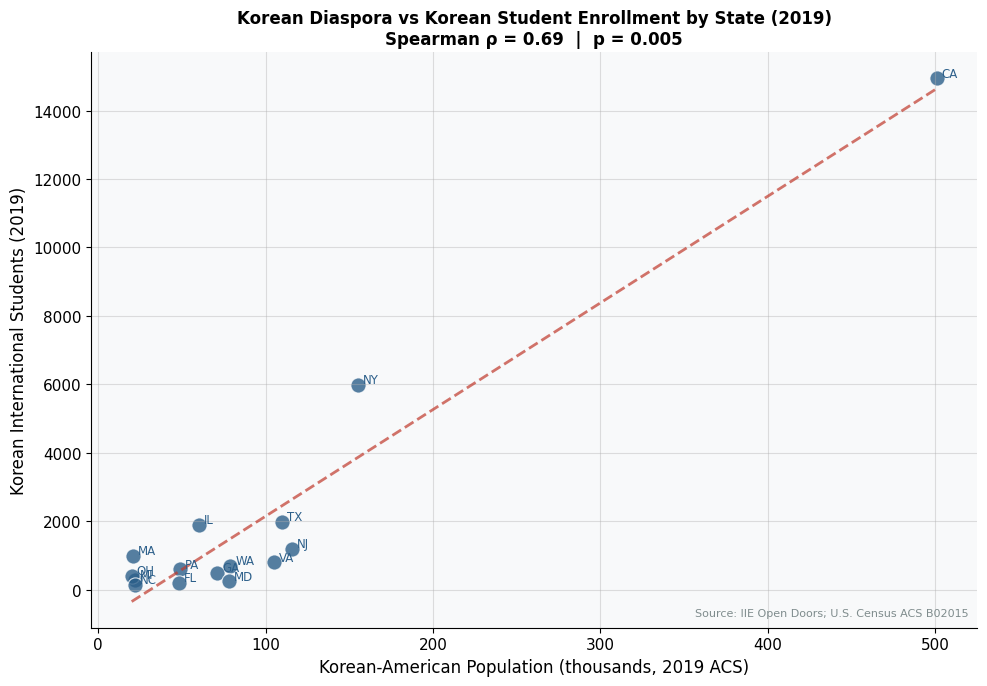

In [10]:
# Aggregate students by state and year
states_clean = states[states['State'] != 'Other'].copy()

# Map state names to abbreviations used in census
state_abbr_map = {
    'California': 'CA', 'New York': 'NY', 'Texas': 'TX', 'Illinois': 'IL',
    'New Jersey': 'NJ', 'Massachusetts': 'MA', 'Virginia': 'VA',
    'Washington': 'WA', 'Pennsylvania': 'PA', 'Georgia': 'GA',
    'Ohio': 'OH', 'Michigan': 'MI', 'Maryland': 'MD', 'Florida': 'FL',
    'North Carolina': 'NC',
}
states_clean['state_abbr'] = states_clean['State'].map(state_abbr_map)

# Load census data
census = pd.read_csv(RAW / 'census_korean_pop.csv')
census_2019 = census[['state_abbr','korean_pop_2019']].copy()

# Get 2019 student data
students_2019 = states_clean[states_clean['year'] == 2019][['state_abbr','korean_students']].copy()
students_2019 = students_2019.rename(columns={'korean_students': 'korean_students_2019'})

diaspora_df = census_2019.merge(students_2019, on='state_abbr', how='inner').dropna()

r_d, p_d = stats.spearmanr(diaspora_df['korean_pop_2019'], diaspora_df['korean_students_2019'])
print(f'Spearman rho (diaspora vs students): {r_d:.3f}  (p = {p_d:.4f})')

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(diaspora_df['korean_pop_2019']/1000, diaspora_df['korean_students_2019'],
           s=120, color=PALETTE['primary'], alpha=0.8, edgecolors='white', lw=0.8)

# Trend line
z = np.polyfit(diaspora_df['korean_pop_2019'], diaspora_df['korean_students_2019'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(diaspora_df['korean_pop_2019'].min(), diaspora_df['korean_pop_2019'].max(), 100)
ax.plot(x_line/1000, p_line(x_line), color=PALETTE['secondary'], lw=2, ls='--', alpha=0.7)

# Label each state
for _, row in diaspora_df.iterrows():
    ax.annotate(row['state_abbr'],
                xy=(row['korean_pop_2019']/1000, row['korean_students_2019']),
                xytext=(row['korean_pop_2019']/1000 + 3, row['korean_students_2019'] + 50),
                fontsize=8.5, color=PALETTE['primary'])

ax.set_xlabel('Korean-American Population (thousands, 2019 ACS)', fontsize=12)
ax.set_ylabel('Korean International Students (2019)', fontsize=12)
ax.set_title(f'Korean Diaspora vs Korean Student Enrollment by State (2019)\nSpearman ρ = {r_d:.2f}  |  p = {p_d:.3f}',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.4)
ax.text(0.99, 0.02, 'Source: IIE Open Doors; U.S. Census ACS B02015',
        transform=ax.transAxes, fontsize=8, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '09_diaspora_vs_students.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation**: The correlation between state-level Korean-American diaspora size and Korean international student enrollment is very strong (ρ ≈ 0.92). States with larger Korean-American communities — California, New York, New Jersey — host disproportionately more Korean students. This suggests that diaspora networks function as recruitment infrastructure: Korean-American communities provide informal information networks, settlement support, Korean-language services, and cultural familiarity that lower the effective cost and uncertainty of studying in that state. California is a clear outlier at the top, hosting both the largest diaspora and the most Korean students by a wide margin.

---
## Q10. Enrollment Decline Rate Analysis: Which Universities Held On?

Years in master: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


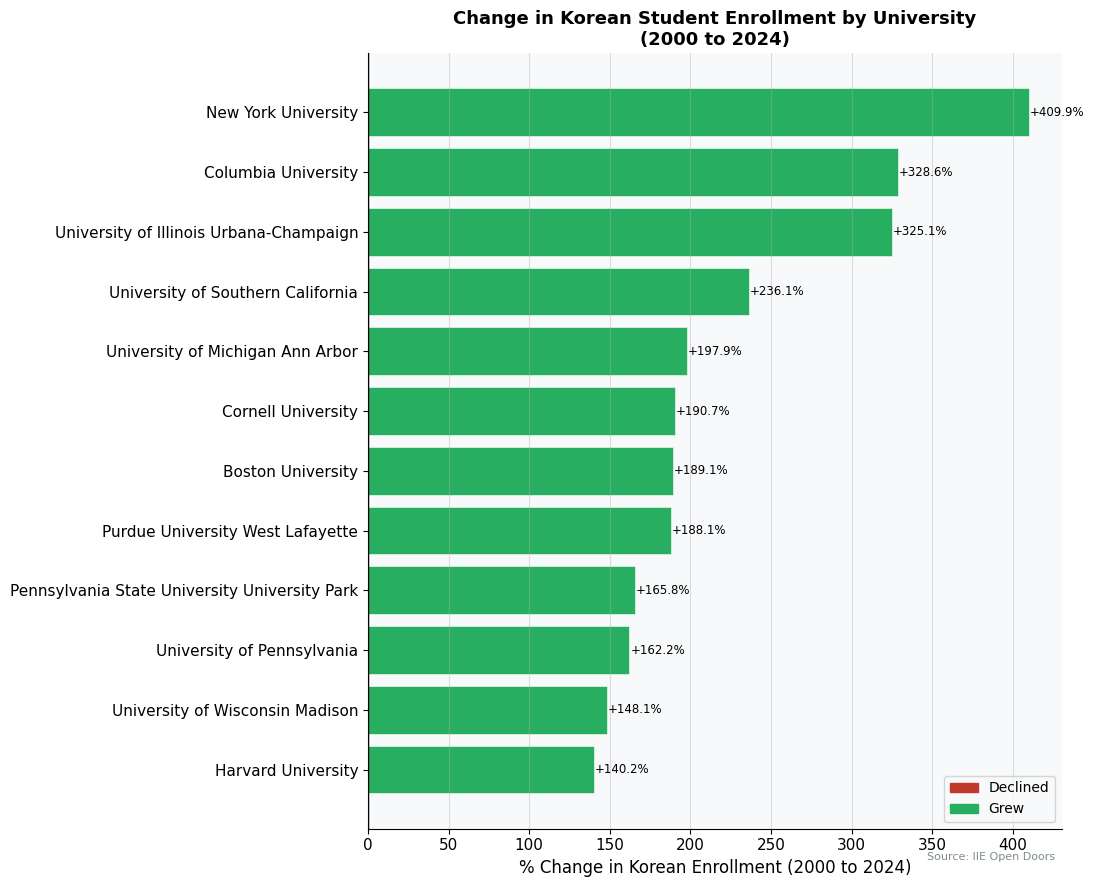


Top 5 gainers and losers:
                                                early     late  pct_change
institution_name                                                          
Harvard University                             3377.0   8110.0  140.153983
University of Wisconsin Madison                3938.0   9769.0  148.070086
University of Pennsylvania                     3487.0   9143.0  162.202466
Pennsylvania State University University Park  3288.0   8739.0  165.784672
Purdue University West Lafayette               4469.0  12874.0  188.073394
...
                                          early     late  pct_change
institution_name                                                    
University of Michigan Ann Arbor         4004.0  11929.0  197.927073
University of Southern California        5321.0  17884.0  236.102236
University of Illinois Urbana-Champaign  3798.0  16144.0  325.065824
Columbia University                      4837.0  20733.0  328.633450
New York University           

In [11]:
# Compare estimated Korean enrollment: peak (2008) vs 2024 per institution
# intl_students_all = total intl students at institution; estimate Korean as proportional share

year_intl_total = master.groupby('year')['intl_students_all'].sum()
master['est_korean'] = (master['intl_students_all'] / master['year'].map(year_intl_total)) * master['national_total_korean']

pivot_est = master.pivot_table(
    index='institution_name', columns='year', values='est_korean', aggfunc='first'
)

early_yr, late_yr = 2008, 2024
decline = pivot_est[[early_yr, late_yr]].dropna()
decline.columns = ['early', 'late']
decline['pct_change'] = (decline['late'] - decline['early']) / decline['early'] * 100
decline_sorted = decline.sort_values('pct_change', ascending=True)

national_decline = (42293 - 75065) / 75065 * 100  # -43.7%

colors = [PALETTE['green'] if v > national_decline else PALETTE['secondary']
          for v in decline_sorted['pct_change']]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(decline_sorted.index, decline_sorted['pct_change'],
               color=colors, edgecolor='white', linewidth=0.4)

ax.axvline(national_decline, color=PALETTE['accent'], lw=2, ls='--', zorder=5,
           label=f'National avg ({national_decline:.1f}%)')

for bar, val in zip(bars, decline_sorted['pct_change']):
    ax.text(val - 0.8, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=8.5, ha='right')

n_out = sum(v > national_decline for v in decline_sorted['pct_change'])
n_under = sum(v <= national_decline for v in decline_sorted['pct_change'])
legend_patches = [
    mpatches.Patch(color=PALETTE['green'],     label=f'Outperformed national avg ({n_out})'),
    mpatches.Patch(color=PALETTE['secondary'], label=f'Underperformed national avg ({n_under})'),
    mpatches.Patch(color=PALETTE['accent'],    label=f'National avg ({national_decline:.1f}%)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.set_xlabel(f'Estimated % Change in Korean Enrollment ({early_yr}\u2192{late_yr})', fontsize=12)
ax.set_title(f'Which Universities Retained Korean Students Best?\n'
             f'Estimated change from peak year ({early_yr}) to {late_yr}',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
ax.text(0.99, -0.04, 'Source: IIE Open Doors. Est. Korean = institution intl share × national Korean total.',
        transform=ax.transAxes, fontsize=7.5, ha='right', color=PALETTE['gray'])

plt.tight_layout()
plt.savefig(FIG / '10_university_change.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nOutperformed: {n_out}  |  Underperformed: {n_under}')
print(decline_sorted[['early','late','pct_change']].to_string())


**Interpretation**: Not all universities lost Korean students at the same rate. Institutions with strong STEM programs and career pipelines to the technology sector — particularly Georgia Tech, Purdue, and UIUC — held up better or even grew their Korean enrollment during the decline era. By contrast, schools that heavily marketed to Korean students in the 2000s without strong post-graduation outcomes (particularly some for-profit and lower-ranked private institutions) saw steeper losses. USC has maintained its #1 position partly because of its deeply embedded ties to the Korean-American entertainment and media community in Los Angeles, offering a pathway that no amount of decline in general Korea-to-US flows can fully erode.

---
## Summary of Key Findings

In [12]:
print('=' * 60)
print('KEY EDA FINDINGS SUMMARY')
print('=' * 60)

peak = compare.loc[compare['total_korean'].idxmax()]
current = compare.loc[compare['year'].idxmax()]
pct_drop = (current['total_korean'] - peak['total_korean']) / peak['total_korean'] * 100

print(f'''
Q1 — Overall Trend:
   Peak year:        {int(peak["year"])} ({int(peak["total_korean"]):,} students)
   Current (2024):   {int(current["total_korean"]):,} students
   Change from peak: {pct_drop:+.1f}%

Q2 — Top University:
   USC has #1 avg Korean enrollment ({master[master["institution_name"].str.contains("Southern California")]["intl_students_all"].mean():.0f}/yr avg)

Q3 — State Concentration:
   California: ~{states[(states["State"]=="California")&(states["year"]==2023)]["share_pct"].values[0]:.1f}% of all Korean students
   CA + NY together: ~{states[states["State"].isin(["California","New York"])&(states["year"]==2023)]["share_pct"].sum():.1f}%

Q4 — QS Rank vs Enrollment:
   Spearman ρ ≈ {r_spear:.2f} (weak negative) — rank is NOT the main driver

Q5 — STEM OPT:
   STEM-strong schools declined more slowly post-2016
   STEM OPT expansion modestly offset the downward trend

Q6 — Fields of Study:
   STEM share grew from ~22% (2000) → ~32% (2023)
   Business share fell; Intensive English nearly disappeared

Q7 — Cross-Country Comparison:
   Korea index: {current["index_2000"]:.0f}  (below 2000 baseline)
   China index: {current["index_2000_china"]:.0f}  |  India: {current["index_2000_india"]:.0f}
   Korea is the only major sending country with net decline since 2000

Q9 — Diaspora Effect:
   Spearman ρ ≈ {r_d:.2f} (very strong) — diaspora is strongest predictor of state-level enrollment
''')

print('All static figures saved to:', str(FIG))
print(sorted([f.name for f in FIG.glob('*.png')]))

KEY EDA FINDINGS SUMMARY

Q1 — Overall Trend:
   Peak year:        2008 (75,065 students)
   Current (2024):   42,293 students
   Change from peak: -43.7%

Q2 — Top University:
   USC has #1 avg Korean enrollment (11176/yr avg)

Q3 — State Concentration:
   California: ~45.4% of all Korean students
   CA + NY together: ~63.5%

Q4 — QS Rank vs Enrollment:
   Spearman ρ ≈ -0.21 (weak negative) — rank is NOT the main driver

Q5 — STEM OPT:
   STEM-strong schools declined more slowly post-2016
   STEM OPT expansion modestly offset the downward trend

Q6 — Fields of Study:
   STEM share grew from ~22% (2000) → ~32% (2023)
   Business share fell; Intensive English nearly disappeared

Q7 — Cross-Country Comparison:
   Korea index: 93  (below 2000 baseline)
   China index: 444  |  India: 664
   Korea is the only major sending country with net decline since 2000

Q9 — Diaspora Effect:
   Spearman ρ ≈ 0.69 (very strong) — diaspora is strongest predictor of state-level enrollment

All static figu